## Wine Quality : EDA

Goal: predict `quality` from 11 lab measurements.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/winequality-red.csv", sep=";")
df.columns = df.columns.str.replace(" " , "_")
print(f"Shape:{df.shape}")

Shape:(1599, 12)


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile_acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric_acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual_sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free_sulfur_dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total_sulfur_dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


### Duplicates Study

In [14]:
print(f"Duplicates:{df.duplicated().sum()}")
df_clean = df.drop_duplicates().reset_index(drop=True)
df_clean.shape

Duplicates:240


(1359, 12)

#### Target

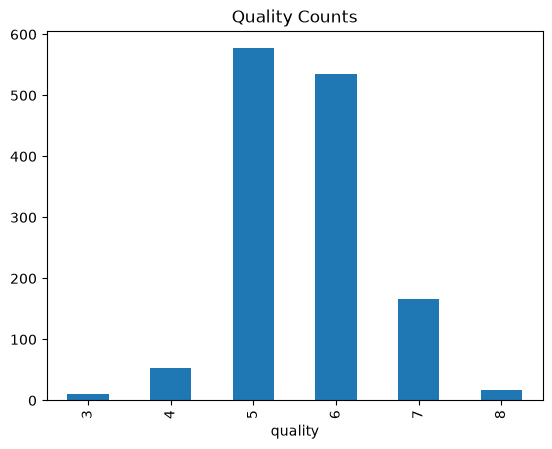

In [15]:
df_clean.quality.value_counts().sort_index().plot(kind="bar")
plt.title("Quality Counts")
plt.show()

#### Correlation with Quality

<function matplotlib.pyplot.show(close=None, block=None)>

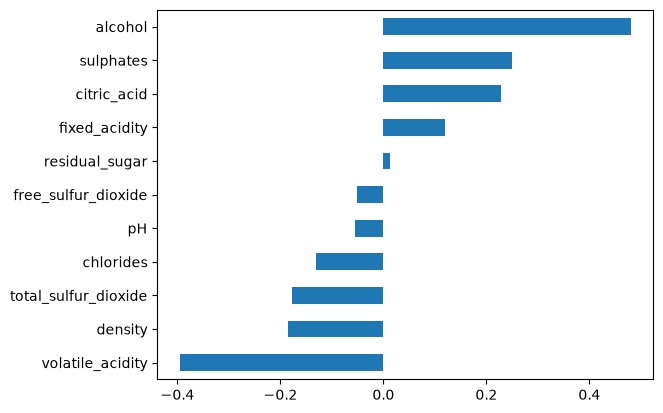

In [16]:
df_clean.corr()["quality"].drop("quality").sort_values().plot(kind="barh")
plt.show

#### Leakage Check

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  r2_score
from sklearn.model_selection import train_test_split

def leakage_check(data):
    X , y = data.drop(columns="quality") , data.quality
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(200, random_state=42, n_jobs=-1).fit(X_train, y_train)

    return r2_score(y_test, model.predict(X_test))

print(f"With Duplicates:{round(leakage_check(df),3)}")
print(f"Without Duplicates:{round(leakage_check(df_clean),3)}")

With Duplicates:0.532
Without Duplicates:0.462


#### Final Verdict

- Target: `quality`, treated as regression.
- Features: all 11 columns.
- Cleaning: drop duplicates. No missing values.
- Metric: MAE against the mean-prediction baseline.